In [3]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [4]:
!pip install pyTsetlinMachineParallel -q

  Preparing metadata (setup.py) ... done


In [27]:
!pip install tmu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 kB 11.7 MB/s eta 0:00:00


In [5]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.6 MB/s eta 0:00:00


In [6]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [46]:
# Find and fix the file directly
import subprocess
result = subprocess.run(['find', '/usr/local/lib', '-path', '*/tmu/clause_bank/clause_bank.py'],
                       capture_output=True, text=True)
filepath = result.stdout.strip()
print(f"Found: {filepath}")

with open(filepath, 'r') as f:
    content = f.read()

fixed = content.replace(
    'np.uint32(~0)',
    'np.iinfo(np.uint32).max'
)

with open(filepath, 'w') as f:
    f.write(fixed)

print("Done — restart your runtime now")

Found: /usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank.py
Done — restart your runtime now


In [2]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
import lime
import lime.lime_tabular
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from pyTsetlinMachineParallel.tm import RegressionTsetlinMachine
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import KBinsDiscretizer
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import pandas as pd
from tmu.models.regression.vanilla_regressor import TMRegressor
from sklearn import linear_model
import math

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv", parse_dates=["date"])


In [8]:
df = df.drop(columns=['gdp'])
df.shape

(140, 24)

In [9]:
def get_model(model_name):
    models = {
        'RF':       RandomForestRegressor(
                        n_estimators=500, max_depth=5,
                        min_samples_leaf=3, random_state=42),
        'GB':       GradientBoostingRegressor(
                        n_estimators=300, learning_rate=0.05,
                        max_depth=3, min_samples_leaf=3,
                        subsample=0.8, random_state=42),
        'XGB':      XGBRegressor(
                        n_estimators=500, learning_rate=0.03,
                        max_depth=3, subsample=0.7,
                        colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=1.0, random_state=42,
                        objective='reg:squarederror'),
        'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
        'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
        'bayes':    BayesianRidge(max_iter=500),
        'catboost': CatBoostRegressor(
                        iterations=500, learning_rate=0.03, depth=4,
                        l2_leaf_reg=5.0, random_state=42, verbose=0)
    }
    return models[model_name]

In [10]:
PARAM_GRIDS = {
    'RF': {
        'model__n_estimators':      [300, 500],
        'model__max_depth':         [3, 5, None],
        'model__min_samples_leaf':  [3, 5, 8],
        'model__min_samples_split': [5, 10],
        'model__max_features':      ['sqrt', 0.5],
    },
    'GB': {
        'model__n_estimators':     [200, 300],
        'model__learning_rate':    [0.01, 0.03, 0.05],
        'model__max_depth':        [2, 3],
        'model__subsample':        [0.6, 0.7],
        'model__min_samples_leaf': [3, 5],
    },
    'XGB': {
        'model__n_estimators':     [300, 500],
        'model__learning_rate':    [0.01, 0.03],
        'model__max_depth':        [2, 3],
        'model__subsample':        [0.6, 0.7],
        'model__colsample_bytree': [0.6, 0.7],
        'model__reg_alpha':        [0.1, 0.5, 1.0],
        'model__reg_lambda':       [1.0, 2.0],
        'model__min_child_weight': [3, 5],
    },
    'KNN': {
        'model__n_neighbors': [5, 7, 10, 15],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan'],
        'model__leaf_size':   [20, 30],
    },
    'SVR': {
        'model__C':       [1.0, 10.0, 50.0],
        'model__epsilon': [0.001, 0.01, 0.05],
        'model__gamma':   ['scale', 'auto'],
        'model__kernel':  ['rbf', 'linear'],
    },
    'bayes': {
        'model__alpha_1':  [1e-7, 1e-6, 1e-5],
        'model__alpha_2':  [1e-7, 1e-6, 1e-5],
        'model__lambda_1': [1e-7, 1e-6, 1e-5],
        'model__lambda_2': [1e-7, 1e-6, 1e-5],
        'model__max_iter': [300, 500, 1000],
    },
    'catboost': {
        'model__iterations':    [300, 500],
        'model__learning_rate': [0.01, 0.03],
        'model__depth':         [3, 4, 5],
        'model__l2_leaf_reg':   [3.0, 5.0, 10.0],
        'model__subsample':     [0.6, 0.7],
    },
}


BASE_MODELS = {
    'RF':       RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB':       GradientBoostingRegressor(random_state=42),
    'XGB':      XGBRegressor(random_state=42, objective='reg:squarederror',
                             tree_method='hist', verbosity=0),
    'KNN':      KNeighborsRegressor(),
    'SVR':      SVR(),
    'bayes':    BayesianRidge(),
    'catboost': CatBoostRegressor(random_state=42, verbose=0),
}

In [11]:
def tune_model(model_name, pre_steps, X_train, y_train,
               n_iter=30, cv_splits=5):
    steps  = pre_steps + [('model', BASE_MODELS[model_name])]
    pipe   = Pipeline(steps)
    tscv   = TimeSeriesSplit(n_splits=cv_splits)
    search = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_GRIDS[model_name],
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'r2',
        random_state       = 42,
        n_jobs             = -1,
        refit              = True
    )
    search.fit(X_train, y_train)
    print(f"  Best CV R²:  {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_


In [12]:
def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)


In [13]:
def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df


In [14]:
def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)


In [15]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()


In [18]:

def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data        = X_train,
        feature_names        = feature_names,
        mode                 = 'regression',
        discretize_continuous= True,
        random_state         = 42
    )

    all_weights = []
    for i in range(len(X_test)):
        exp          = explainer.explain_instance(
            X_test[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 500
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':     feature_names,
        'importance':  lime_df.abs().mean().values,
        'mean_effect': lime_df.mean().values,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name})\nBlue=increases GDP, Red=decreases GDP")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime


In [19]:

def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names, model_name,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        plot_macro_bar(fi_standard, f"Standard Importance — All Macro\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


In [20]:

def run_arima(y_train, y_test, test_dates, X_train=None, X_test=None, use_macro=False):
    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 4]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 4),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue

    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)
    results = pd.DataFrame({
        "date":          test_dates.values,
        "gdp_growth":    y_test.values,
        "predicted_gdp": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best order AIC: {best_aic:.2f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['gdp_growth'] - row['predicted_gdp'])
        print(f"{str(row['date'])[:10]:<15} {row['gdp_growth']:>12.2f} {row['predicted_gdp']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.4f}")
    print(f"{'MAE:':>45}  {mae:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["gdp_growth"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("GDP")
    ax.set_title(f"GDP Prediction — ARIMA\n(R²={r2:.3f}  RMSE={rmse:.4f}  MAE={mae} MAPE={mape:.1f}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, mae, rmse, mape, r2


In [21]:
from sklearn.decomposition import PCA

def build_pca_step(X_train, n_features, print_variance=False):
    n_samples, n_raw = X_train.shape
    n_components = min(n_features, n_samples, n_raw)

    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_train)

    if print_variance:
        cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
        print(f"\n  PCA: kept {n_components} components from {n_raw} features")
        print(f"  {'PC':<6} {'Var %':>8} {'Cumul %':>10}")
        print(f"  {'-'*26}")
        for i, (ev, cv) in enumerate(
                zip(pca.explained_variance_ratio_ * 100, cum_var)):
            print(f"  PC{i+1:<4} {ev:>8.2f} {cv:>10.2f}")
        print(f"  → {cum_var[-1]:.1f}% variance retained")

    return pca, n_components

In [34]:

def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy,  epochs=30, tune=True, n_trials=30,use_macro=True):

    if not use_macro:
        drop_cols = [c for c in X_train.columns
                     if any(c == m or c.startswith(f"{m}_") for m in macro_vars)]
        X_train = X_train.drop(columns=drop_cols, errors='ignore')
        X_test  = X_test.drop(columns=drop_cols, errors='ignore')
        feature_names = X_train.columns.tolist()

    X_train = X_train.values
    X_test  = X_test.values

    scaler = RobustScaler()

    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    TOP_K_SEL = min(15, X_tr_sc.shape[1])
    selector = SelectKBest(
        score_func=f_regression,
        k=TOP_K_SEL
    )

    X_tr_sel = selector.fit_transform(X_tr_sc, y_train)
    X_te_sel = selector.transform(X_te_sc)

    selected_features = np.array(feature_names)[selector.get_support()].tolist()

    model = XGBRegressor(
                        n_estimators=500, learning_rate=0.03,
                        max_depth=3, subsample=0.6,
                        colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=2.0, random_state=42,
                        objective='reg:squarederror')
    model.fit(X_tr_sel, y_train)

    train_pred = model.predict(X_tr_sel)
    test_pred = model.predict(X_te_sel)
    base_r2 = r2_score(y_test, test_pred)

    y_train_arr = np.asarray(y_train, dtype=np.float32)
    y_test_arr = np.asarray(y_test, dtype=np.float32)
    residuals = y_train_arr - train_pred.astype(np.float32)
    resid_mean = float(np.mean(residuals))
    resid_std = float(np.std(residuals))
    if resid_std <= 1e-6:
        resid_std = 1.0

    resid_sc = ((residuals - resid_mean) / resid_std).astype(np.float32)
    booleaniser = KBinsDiscretizer(
        n_bins=10,
        encode='ordinal',
        strategy='quantile'
    )
    X_tr_bits = booleaniser.fit_transform(X_tr_sel).astype(np.uint32)
    X_te_bits = booleaniser.transform(X_te_sel).astype(np.uint32)


    if tune:
        split = int(0.8 * len(X_tr_bits))
        X_opt_tr = X_tr_bits[:split]
        y_opt_tr = resid_sc[:split]
        X_opt_val = X_tr_bits[split:]
        y_opt_val = resid_sc[split:]
        y_full_val = y_train_arr[split:]
        base_val = train_pred[split:].astype(np.float32)

        def objective(trial):
            clauses = trial.suggest_int("number_of_clauses", 50, 500)
            T = trial.suggest_int("T", 10, 100)
            s = trial.suggest_float("s", 1.2, 5.0)

            tm = TMRegressor(
                number_of_clauses=clauses,
                T=T,
                s=s,
                seed=42,
                weighted_clauses=True
            )
            for _ in range(30):
                tm.fit(X=X_opt_tr, Y=y_opt_tr)
            resid_pred = tm.predict(X_opt_val).astype(np.float32)
            y_pred_val = (base_val +(resid_pred * resid_std + resid_mean))
            return math.sqrt(mean_squared_error(y_full_val, y_pred_val))

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=True
        )
        best = study.best_params
    else:
        best = {"number_of_clauses": 200, "T": 50, "s": 2.5}

    tm = TMRegressor(
        **best,
        seed=42,
        weighted_clauses=True
    )

    for _ in range(epochs):
        tm.fit(X=X_tr_bits, Y=resid_sc)

    resid_pred_te = tm.predict(X_te_bits).astype(np.float32)
    tm_correction = (
        resid_pred_te * resid_std + resid_mean
    )

    clip_val = float(np.abs(residuals).max()) * 2.0
    tm_correction = np.clip(
        tm_correction,
        -clip_val,
        clip_val
    )

    y_pred = (
        test_pred.astype(np.float32)
        + 0.2 * tm_correction
    )
    resid_pred_tr = tm.predict(X_tr_bits).astype(np.float32)
    y_pred_tr = (
        train_pred.astype(np.float32)
        + np.clip(
            resid_pred_tr * resid_std + resid_mean,
            -clip_val,
            clip_val))

    calibrator = LinearRegression()

    calibrator.fit(
        y_pred_tr.reshape(-1, 1),
        y_train_arr
    )

    y_pred = calibrator.predict(
        y_pred.reshape(-1, 1)
    ).ravel().astype(np.float32)

    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae = mean_absolute_error(y_test_arr, y_pred)
    mape = (mean_absolute_percentage_error( y_test_arr, y_pred) * 100 )
    r2 = r2_score(y_test_arr, y_pred)
    results = pd.DataFrame({
        "date": test_dates,
        "actual": y_test_arr,
        "predicted": y_pred,
        "base_prediction": test_pred
    })

    fi_perm = None
    try:
        perm = permutation_importance(
            model,
            X_te_sel,
            y_test,
            n_repeats=10,
            random_state=42,
            scoring='neg_root_mean_squared_error'
        )

        fi_perm = pd.DataFrame({
            "feature": selected_features,
            "importance": perm.importances_mean
        }).sort_values(
            "importance",
            ascending=False
        )

    except Exception as e:
        print(f"Permutation importance failed: {e}")

    print(f"\n{'='*65}")
    print("Bayes + Tsetlin Residual Corrector")
    print(
        f"Base R²: {base_r2:.4f} "
        f"→ Final R²: {r2:.4f}"
    )
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")

    for _, row in results.iterrows():
        error = abs(row['actual'] - row['predicted'])
        print(
            f"{str(row['date'])[:10]:<15} "
            f"{row['actual']:>12.2f} "
            f"{row['predicted']:>12.2f} "
            f"{error:>12.2f}"
        )

    print(f"{'-'*65}")
    print(f"{'MAE:':>45} {mae:.4f}")
    print(f"{'RMSE:':>45} {rmse:.4f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"{'='*65}")


    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual"], marker="o", label="Actual", linewidth=2)
    ax.plot(x, results["base_prediction"], marker="s", label="Base Bayesian net", linewidth=1.5, linestyle="--", alpha=0.6)
    ax.plot(x, results["predicted"], marker="o", label="TM Corrected", linewidth=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels(
        [str(d)[:10] for d in results["date"]],
        rotation=45
    )
    ax.set_xlabel("Quarter")
    ax.set_ylabel("CPI Growth (%)")
    ax.set_title(
        f"CPI Growth Forecast\n"
        f"Base R²={base_r2:.3f} → Final R²={r2:.3f} | "
        f"RMSE={rmse:.4f}"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2, fi_perm

In [35]:
macro_vars = [
        "b30ret","b20ret","b10ret","b7ret","b5ret","b2ret","b1ret",
        "t90ret","t30ret","cpiret","wti_price","fedfunds","nfci","anfci",
        "nfci_risk","nfci_credit","nfci_leverage","nfci_nonfinancial_leverage",
        "ppi","trade_balance","unrate","usd_index"
    ]

def GDP_prediction(data, use_macro, model,
                   use_scaling, test_quarters=8,
                   use_lags=True, use_rolling=True,
                   feature_selection=False, n_features=15,
                   importance_strategy='standard',
                   tune=True, n_iter=30, cv_splits=5):

    df = data.copy().sort_values("date").reset_index(drop=True)

    if use_lags:
        for lag in [1, 2, 4]:
            df[f"gdp_lag{lag}"] = df["gdp_growth"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)

    if use_rolling:
        for w in [4, 8]:
            df[f"gdp_roll{w}"] = df["gdp_growth"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    X = df.drop(columns=["gdp_growth", "date"])
    y = df["gdp_growth"]

    X_train       = X.iloc[:-test_quarters]
    X_test        = X.iloc[-test_quarters:]
    y_train       = y.iloc[:-test_quarters]
    y_test        = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    if model == 'arima':
        return run_arima(
            y_train   = y_train,
            y_test    = y_test,
            test_dates= test_dates,
            X_train   = X_train.values if use_macro else None,
            X_test    = X_test.values  if use_macro else None,
            use_macro = use_macro
        )

    if model == 'tsetlin':
          return run_tsetlin(
              X_train             = X_train,
              X_test              = X_test,
              y_train             = y_train,
              y_test              = y_test,
              test_dates          = test_dates,
              feature_names       = feature_names,
              importance_strategy = importance_strategy,
              tune                = tune,
              use_macro           = use_macro,
          )

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")

    pre_steps = []
    if use_scaling or feature_selection == 'PCA':
        pre_steps.append(('scaler', RobustScaler()))

    if feature_selection == 'PCA':
        _scaler_tmp = RobustScaler().fit(X_train)
        X_train_scaled_tmp = _scaler_tmp.transform(X_train)

        pca, n_components = build_pca_step(
            X_train_scaled_tmp, n_features, print_variance=True
        )
        pre_steps.append(('pca', pca))

    elif feature_selection: #SelectKBest
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        pipeline = tune_model(model, pre_steps, X_train, y_train,
                              n_iter=n_iter, cv_splits=cv_splits)
    else:
        pre_steps.append(('model', get_model(model)))
        pipeline = Pipeline(pre_steps)
        pipeline.fit(X_train, y_train)
    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":          test_dates.values,
        "gdp_growth":    y_test.values,
        "predicted_gdp": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['gdp_growth'] - row['predicted_gdp'])
        print(f"{str(row['date'])[:10]:<15} {row['gdp_growth']:>12.2f} {row['predicted_gdp']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.4f}")
    print(f"{'MAE:':>45}  {mae:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    if feature_selection == 'PCA':
        fitted_pca      = pipeline.named_steps['pca']
        n_components    = fitted_pca.n_components_
        feat_names_used = [f'PC{i+1}' for i in range(n_components)]
        X_train_arr     = pipeline[:-1].transform(X_train)

        loadings = pd.DataFrame(
            fitted_pca.components_.T,
            index   = feature_names,
            columns = feat_names_used
        )
        print(f"\n  PCA Loadings — top 5 original features per component:")
        for pc in feat_names_used:
            top5 = loadings[pc].abs().nlargest(5).index.tolist()
            print(f"    {pc}: {', '.join(top5)}")

    elif feature_selection:
        selected_mask   = pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax_pred.plot(x, results["gdp_growth"],   marker="o", label="Actual",    linewidth=2)
    ax_pred.plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    ax_pred.set_xticks(x)
    ax_pred.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax_pred.set_xlabel("Quarter")
    ax_pred.set_ylabel("GDP")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"GDP Prediction — {model} ({tuned_label})\n(R²={r2:.3f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = pipeline[:-1].transform(X_test) if (use_scaling or feature_selection=='PCA') else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        model_name    = model,
        X_test        = X_test_arr
    )

    return results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime


  0%|          | 0/30 [00:00<?, ?it/s]


Bayes + Tsetlin Residual Corrector
Base R²: 0.1673 → Final R²: 0.1025
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                         MAE: 0.0025
                                        RMSE: 0.0030
                                    MAPE (%): 18.97
                                          R²: 0.1025


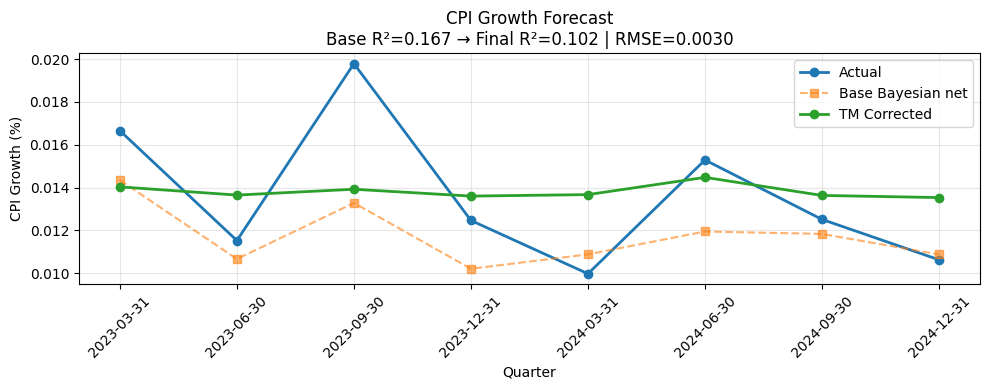

In [36]:
results, rmse, mae, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True,  importance_strategy = 'shap',
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 49

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:       0.0028
                                         MAE:        0.0020
                                    MAPE (%):        13.08
                                          R²:       0.2338


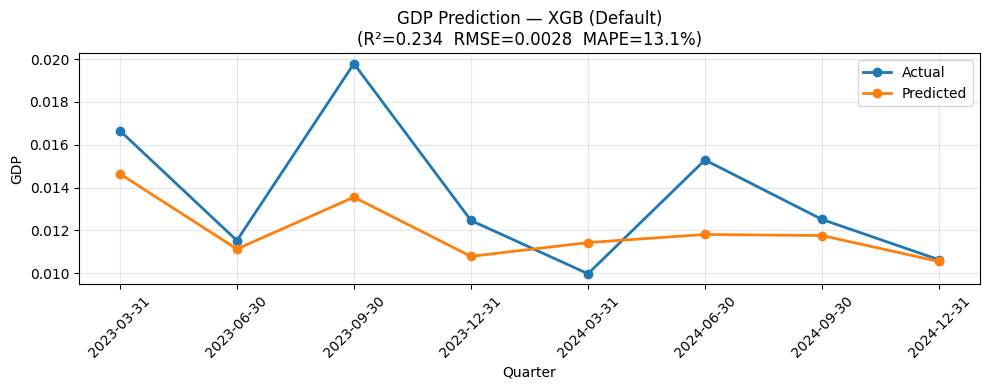

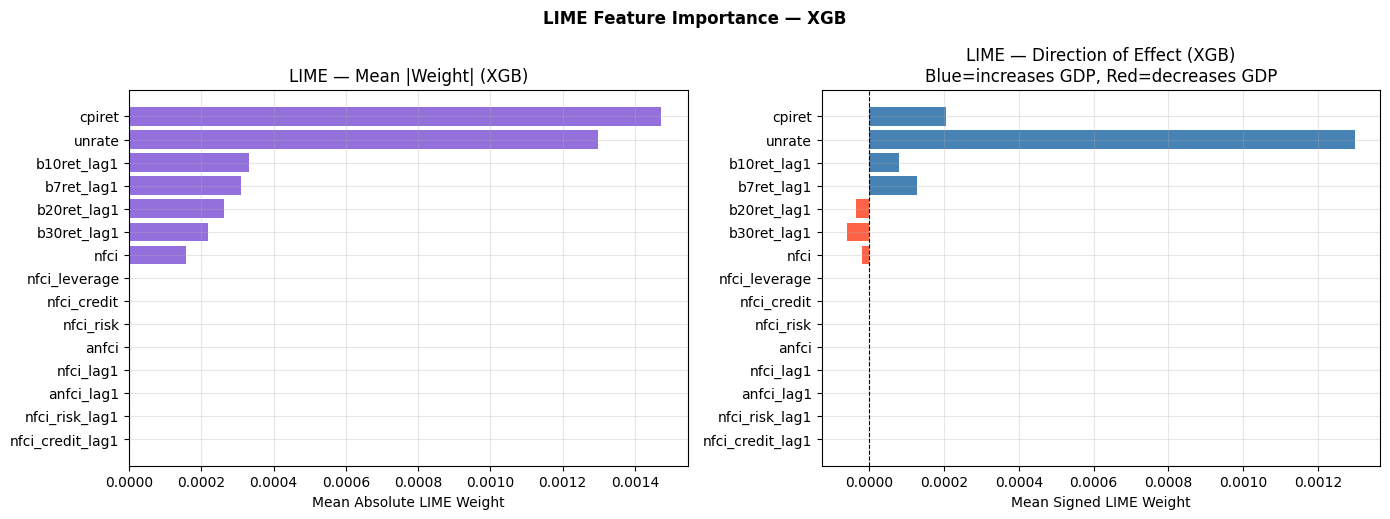

In [31]:
results, rmse, mae, mape, r2, xgb_fi_standard, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    importance_strategy = 'lime',
    feature_selection=True,
    tune=False,


)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best order AIC: -913.66
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.02         0.01
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
                                        RMSE:       0.0045
                                         MAE:        0.0033
                                    MAPE (%):        27.99
                                          R²:      -1.0172


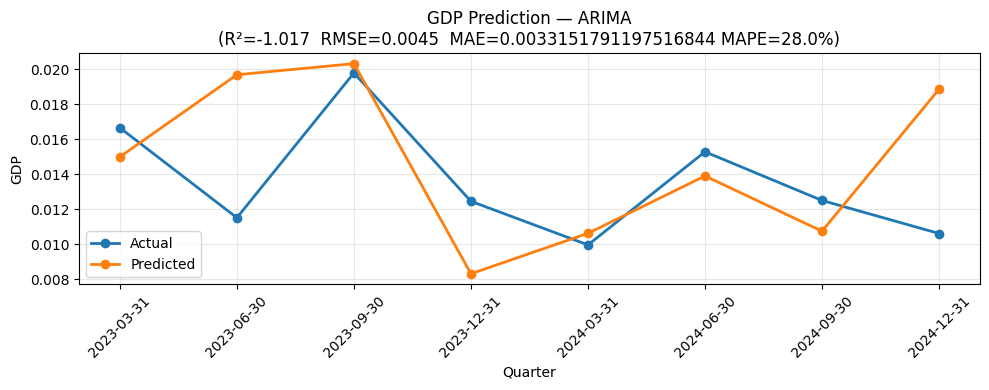

In [ ]:
results, rmse, mae, mape, r2= GDP_prediction(
    df,
    use_macro=True,
    model='arima',
    use_scaling=True,
    feature_selection=True, importance_strategy = 'lime',
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 49

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.02         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:       0.0025
                                         MAE:        0.0021
                                    MAPE (%):        16.31
                                          R²:       0.3744


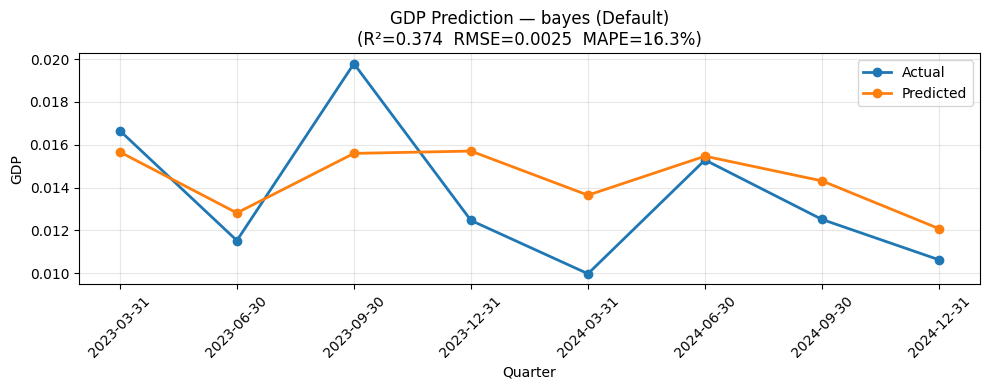

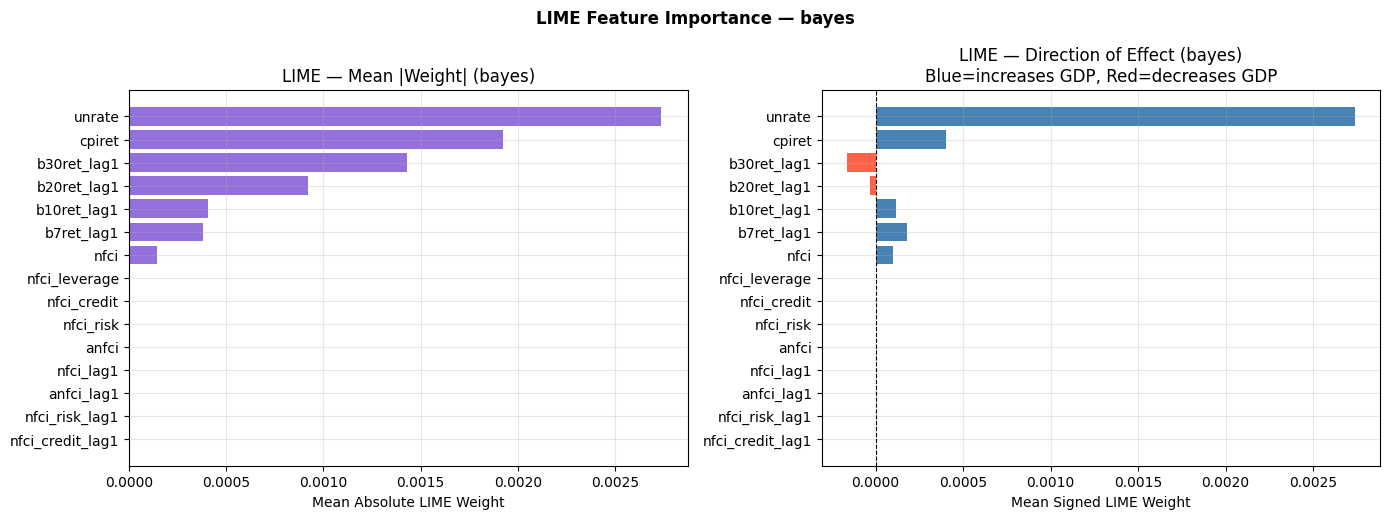

In [ ]:
Results, rmse, mae, mape, r2, bayes_fi_standard, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    feature_selection=True, importance_strategy = 'lime',
    tune=False
)

Total: 132 | Train: 124 | Test: 8 | Features: 49

Tuning SVR with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.2724
  Best params: {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__epsilon': 0.01, 'model__C': 10.0}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:       0.0026
                                         MAE:        0.0023
                    

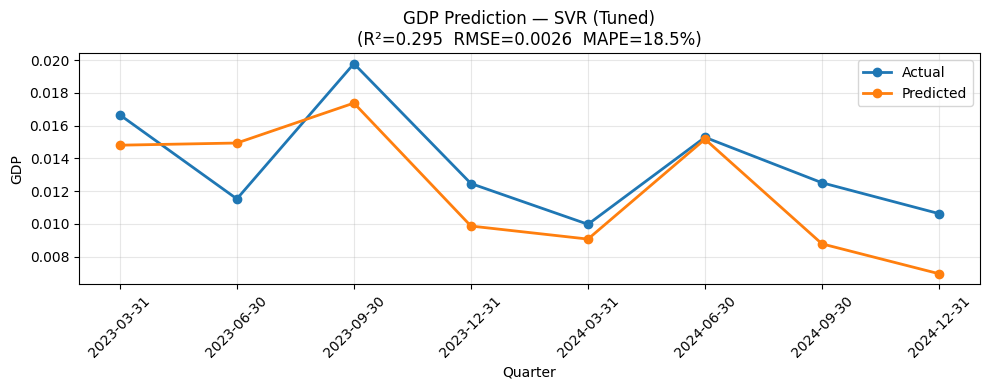

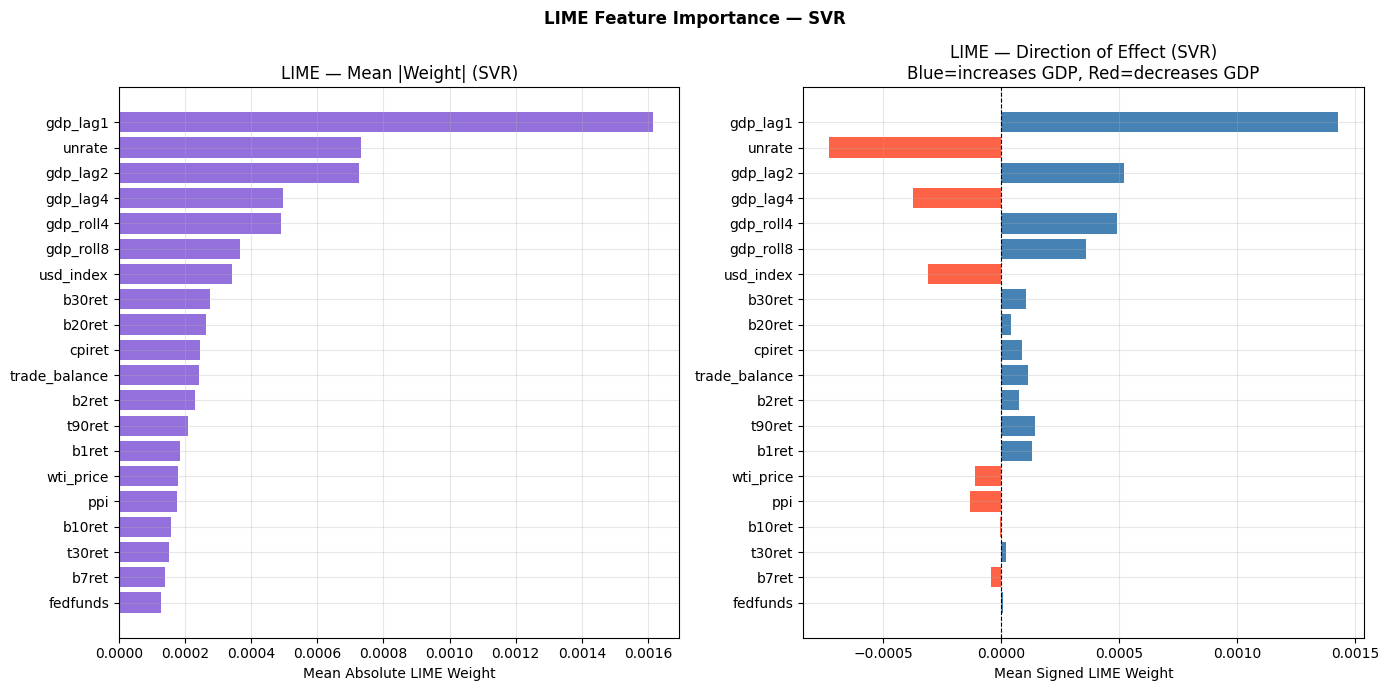

In [ ]:
results, rmse, mae, mape, r2, svr_fi_standard, svr_fi_shap, svr_fi_perm, svr_fi_lime = GDP_prediction(
    df,
    use_macro=True,
    model='SVR',
    use_scaling=True, importance_strategy = 'lime',
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 49

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.1822
  Best params: {'model__subsample': 0.6, 'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_depth': 2, 'model__learning_rate': 0.01}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:       0.0033
                                    

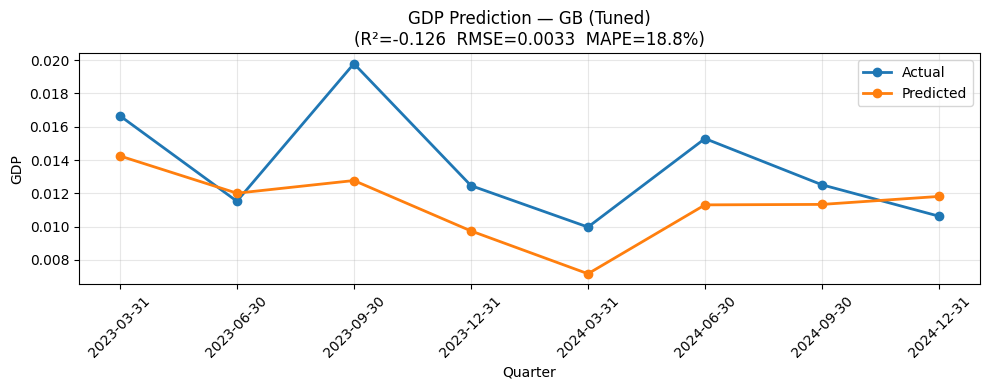

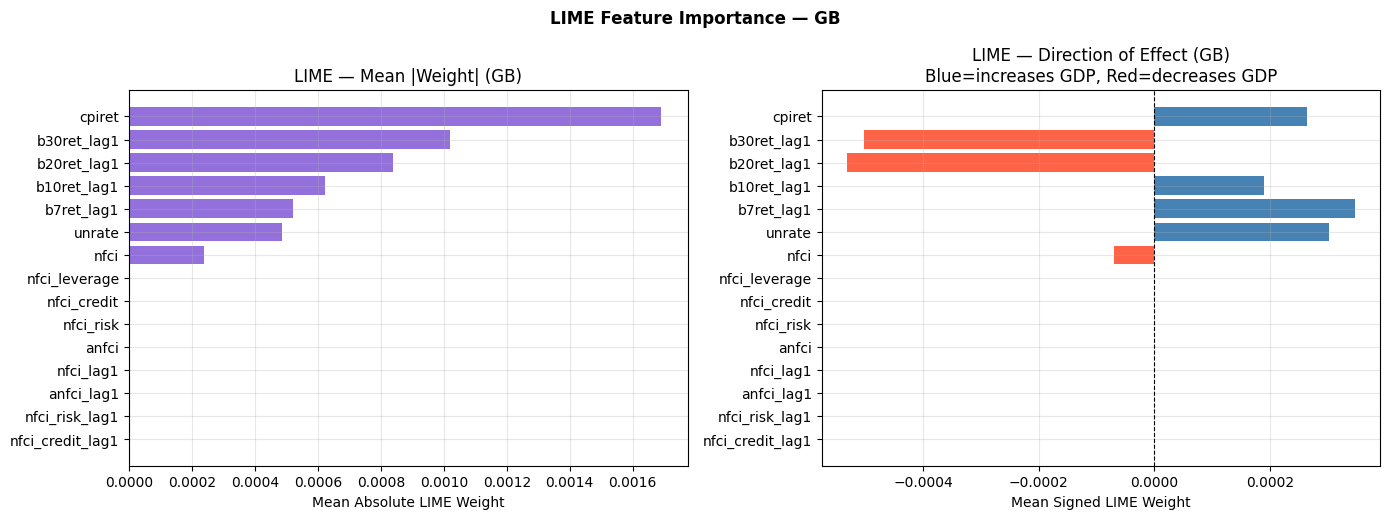

In [ ]:
results, rmse, mae, mape, r2, gb_fi_standard, gb_fi_shap, gb_fi_perm, gb_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='GB',
    use_scaling=True,
    feature_selection=True, importance_strategy = 'lime',
    tune=True
)

Total: 132 | Train: 124 | Test: 8 | Features: 49

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.1921
  Best params: {'model__subsample': 0.6, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 3.0, 'model__iterations': 500, 'model__depth': 3}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.01         0.01
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:       0.0033
                                       

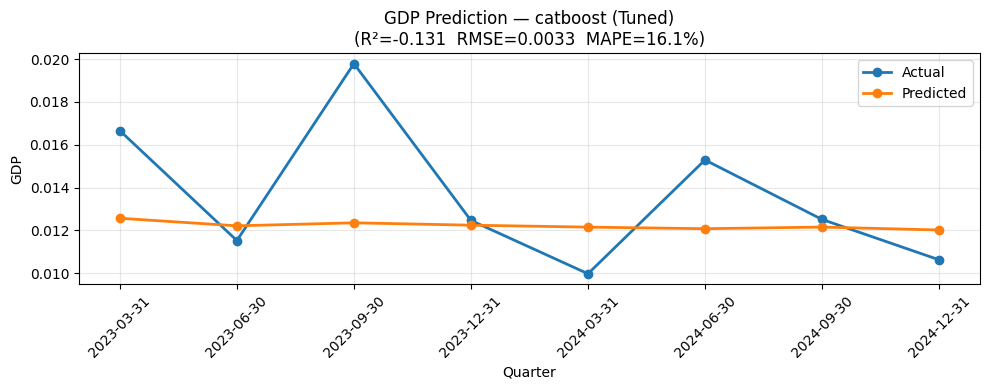

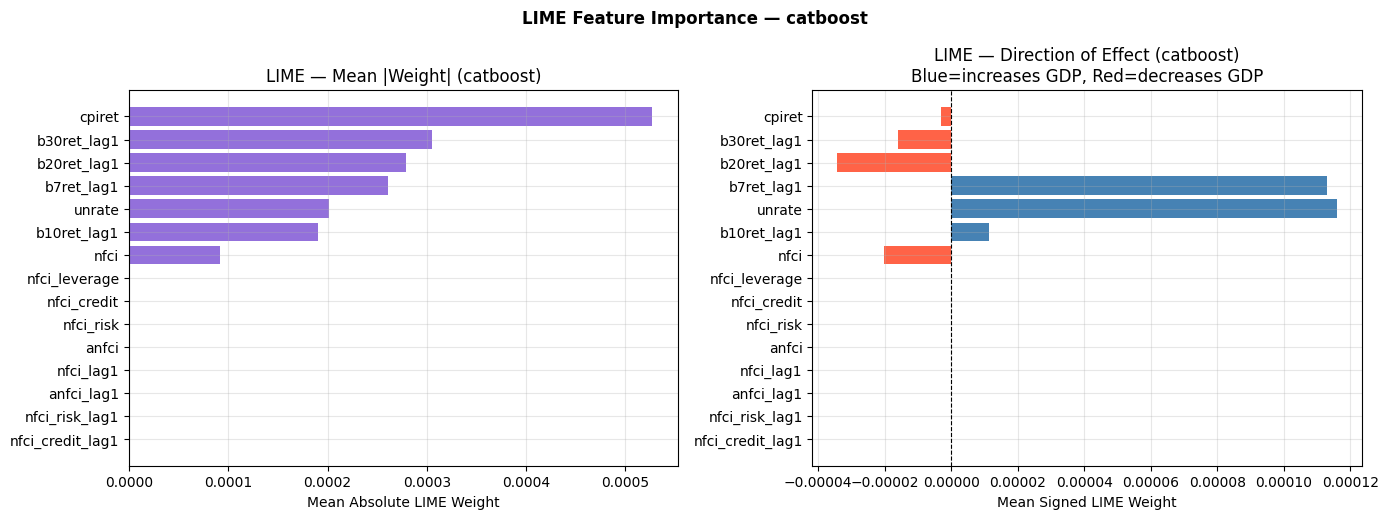

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_standard, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime= GDP_prediction(
    df,
    use_macro=True,
    model='catboost',
    use_scaling=True,
    feature_selection=True, importance_strategy = 'lime',
    tune=True
)

## Aggregate feature importance

In [ ]:

def _build_matrices(importance_results: dict):
    model_names  = list(importance_results.keys())
    n_models     = len(model_names)
    all_features = sorted(
        set(f for fi in importance_results.values() for f in fi['feature'])
    )
    n_features   = len(all_features)

    rank_matrix  = pd.DataFrame(index=all_features, columns=model_names, dtype=float)
    score_matrix = pd.DataFrame(index=all_features, columns=model_names, dtype=float)

    for model_name, fi_df in importance_results.items():
        fi_df = fi_df.copy().reset_index(drop=True)
        fi_df['rank'] = fi_df['importance'].rank(ascending=False, method='min')

        imp_min = fi_df['importance'].min()
        imp_max = fi_df['importance'].max()
        denom   = imp_max - imp_min if imp_max != imp_min else 1.0
        fi_df['norm_score'] = (fi_df['importance'] - imp_min) / denom

        for _, row in fi_df.iterrows():
            rank_matrix.loc[row['feature'],  model_name] = row['rank']
            score_matrix.loc[row['feature'], model_name] = row['norm_score']

        for f in set(all_features) - set(fi_df['feature']):
            rank_matrix.loc[f,  model_name] = n_features + 1
            score_matrix.loc[f, model_name] = 0.0

    return model_names, all_features, n_features, rank_matrix, score_matrix

In [ ]:

def _compute_all_methods(model_names, all_features, n_features,
                          rank_matrix, score_matrix) -> pd.DataFrame:
    borda_scores = sum((n_features + 1) - rank_matrix[m] for m in model_names)
    mean_rank    = rank_matrix.mean(axis=1)
    std_rank     = rank_matrix.std(axis=1)
    mean_score   = score_matrix.mean(axis=1)
    std_score    = score_matrix.std(axis=1)

    return pd.DataFrame({
        'feature':     all_features,
        'borda_score': borda_scores.values,
        'mean_rank':   mean_rank.values,
        'std_rank':    std_rank.values,
        'mean_score':  mean_score.values,
        'std_score':   std_score.values,
        'consistency': (1 / (std_rank.values + 1e-6)),
    })

In [ ]:


def _plot_bar(ax, features, scores, errs, title, xlabel,
              color, invert_x=False):
    if not features:
        ax.text(0.5, 0.5, 'No features', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
        return

    y = range(len(features))
    if errs is not None:
        ax.barh(list(y), scores, xerr=errs, color=color,
                alpha=0.85, capsize=3, edgecolor='white', linewidth=0.4)
    else:
        ax.barh(list(y), scores, color=color,
                alpha=0.85, edgecolor='white', linewidth=0.4)

    ax.set_yticks(list(y))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    if invert_x:
        ax.invert_xaxis()
    ax.grid(True, axis='x', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    for i, s in enumerate(scores):
        ax.text(s * (0.98 if not invert_x else 1.02), i, f"{s:.3f}",
                va='center', ha='right' if not invert_x else 'left',
                fontsize=7, color='#333333')


In [ ]:

def aggregate_feature_importance(importance_results: dict,
                                  top_n: int = 20) -> pd.DataFrame:

    model_names, all_features, n_features, rank_matrix, score_matrix = \
        _build_matrices(importance_results)

    combined = _compute_all_methods(
        model_names, all_features, n_features, rank_matrix, score_matrix
    )

    n_models = len(model_names)

    for sort_col, ascending, label in [
        ('borda_score', False, 'BORDA COUNT'),
        ('mean_rank',   True,  'MEAN RANK'),
        ('mean_score',  False, 'MEAN NORMALISED SCORE'),
    ]:
        ranked = combined.sort_values(sort_col, ascending=ascending).head(top_n)
        print(f"\n{'='*70}")
        print(f"AGGREGATED FEATURE IMPORTANCE — {label} ({n_models} models)")
        print(f"{'='*70}")
        print(f"{'Rank':<6} {'Feature':<35} {'Borda':>8} "
              f"{'MeanRank':>10} {'MeanScore':>10}")
        print(f"{'-'*70}")
        for i, (_, row) in enumerate(ranked.iterrows()):
            print(f"{i+1:<6} {row['feature']:<35} "
                  f"{row['borda_score']:>8.1f} "
                  f"{row['mean_rank']:>10.2f} "
                  f"{row['mean_score']:>10.4f}")
        print(f"{'='*70}")


    METHOD_CFG = [
        ('borda_score', False, 'borda_score', None,
         'Borda Score (higher = more important)', '#2E86AB', False),
        ('mean_rank',   True,  'mean_rank',   'std_rank',
         'Mean Rank (lower = more important, ±std)', '#E07A5F', True),
        ('mean_score',  False, 'mean_score',  'std_score',
         'Mean Normalised Score (higher = more important, ±std)', '#3D9970', False),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(21, max(6, top_n * 0.4)),
                             constrained_layout=True)
    fig.suptitle('GDP Feature Importance Aggregation',
                 fontsize=13, fontweight='bold')

    for ax, (sort_col, ascending, score_col, err_col,
             xlabel, color, invert_x) in zip(axes, METHOD_CFG):

        subset   = combined.sort_values(sort_col, ascending=ascending).head(top_n)
        features = subset['feature'].tolist()[::-1]
        scores   = subset[score_col].tolist()[::-1]
        errs     = subset[err_col].tolist()[::-1] if err_col else None

        _plot_bar(ax, features, scores, errs,
                  xlabel.split('(')[0].strip(), xlabel, color, invert_x)

    plt.savefig("feature_importance_GDP.png", dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

    return combined


In [ ]:

def plot_model_agreement(importance_results: dict, top_n: int = 10) -> pd.DataFrame:
    model_names = list(importance_results.keys())
    vote_counts = {}

    for fi_df in importance_results.values():
        for f in fi_df.nlargest(top_n, 'importance')['feature']:
            vote_counts[f] = vote_counts.get(f, 0) + 1

    vote_df = (pd.DataFrame({
        'feature': list(vote_counts.keys()),
        'votes':   list(vote_counts.values()),
    }).sort_values('votes', ascending=False).reset_index(drop=True))

    print(f"\n{'='*55}")
    print(f"MODEL AGREEMENT — Top {top_n} features per model")
    print(f"{'='*55}")
    for _, row in vote_df.iterrows():
        bar = '█' * row['votes']
        pct = row['votes'] / len(model_names) * 100
        print(f"  {row['feature']:<30} {bar:<10} "
              f"{row['votes']}/{len(model_names)} ({pct:.0f}%)")
    print(f"{'='*55}")

    fig, ax = plt.subplots(figsize=(8, max(4, len(vote_df) * 0.35)))
    colors = ['darkgreen' if v == len(model_names)
              else 'steelblue' if v >= len(model_names) * 0.6
              else 'salmon'
              for v in vote_df['votes'][::-1]]
    ax.barh(vote_df['feature'][::-1], vote_df['votes'][::-1], color=colors)
    ax.axvline(len(model_names), color='black', linestyle='--',
               linewidth=1, label=f'All {len(model_names)} models')
    ax.axvline(len(model_names) * 0.6, color='orange', linestyle='--',
               linewidth=1, label='60% of models')
    ax.set_xlabel(f"Number of models featuring in top {top_n}")
    ax.set_title(f"Feature Agreement Across Models\n"
                 f"(green = in top {top_n} of ALL models)")
    ax.set_xlim(0, len(model_names) + 0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return vote_df


AGGREGATED FEATURE IMPORTANCE — BORDA COUNT (4 models)
Rank   Feature                                Borda   MeanRank  MeanScore
----------------------------------------------------------------------
1      cpiret                                  59.0       1.25     0.8861
2      b30ret_lag1                             51.0       3.25     0.4604
3      b20ret_lag1                             50.0       3.50     0.3892
4      unrate                                  50.0       3.50     0.6164
5      b10ret_lag1                             46.0       4.50     0.2978
6      b7ret_lag1                              44.0       5.00     0.2952
7      nfci                                    36.0       7.00     0.1175
8      anfci                                   32.0       8.00     0.0000
9      anfci_lag1                              32.0       8.00     0.0000
10     nfci_credit_lag1                        32.0       8.00     0.0000
11     nfci_credit                             32.0       8

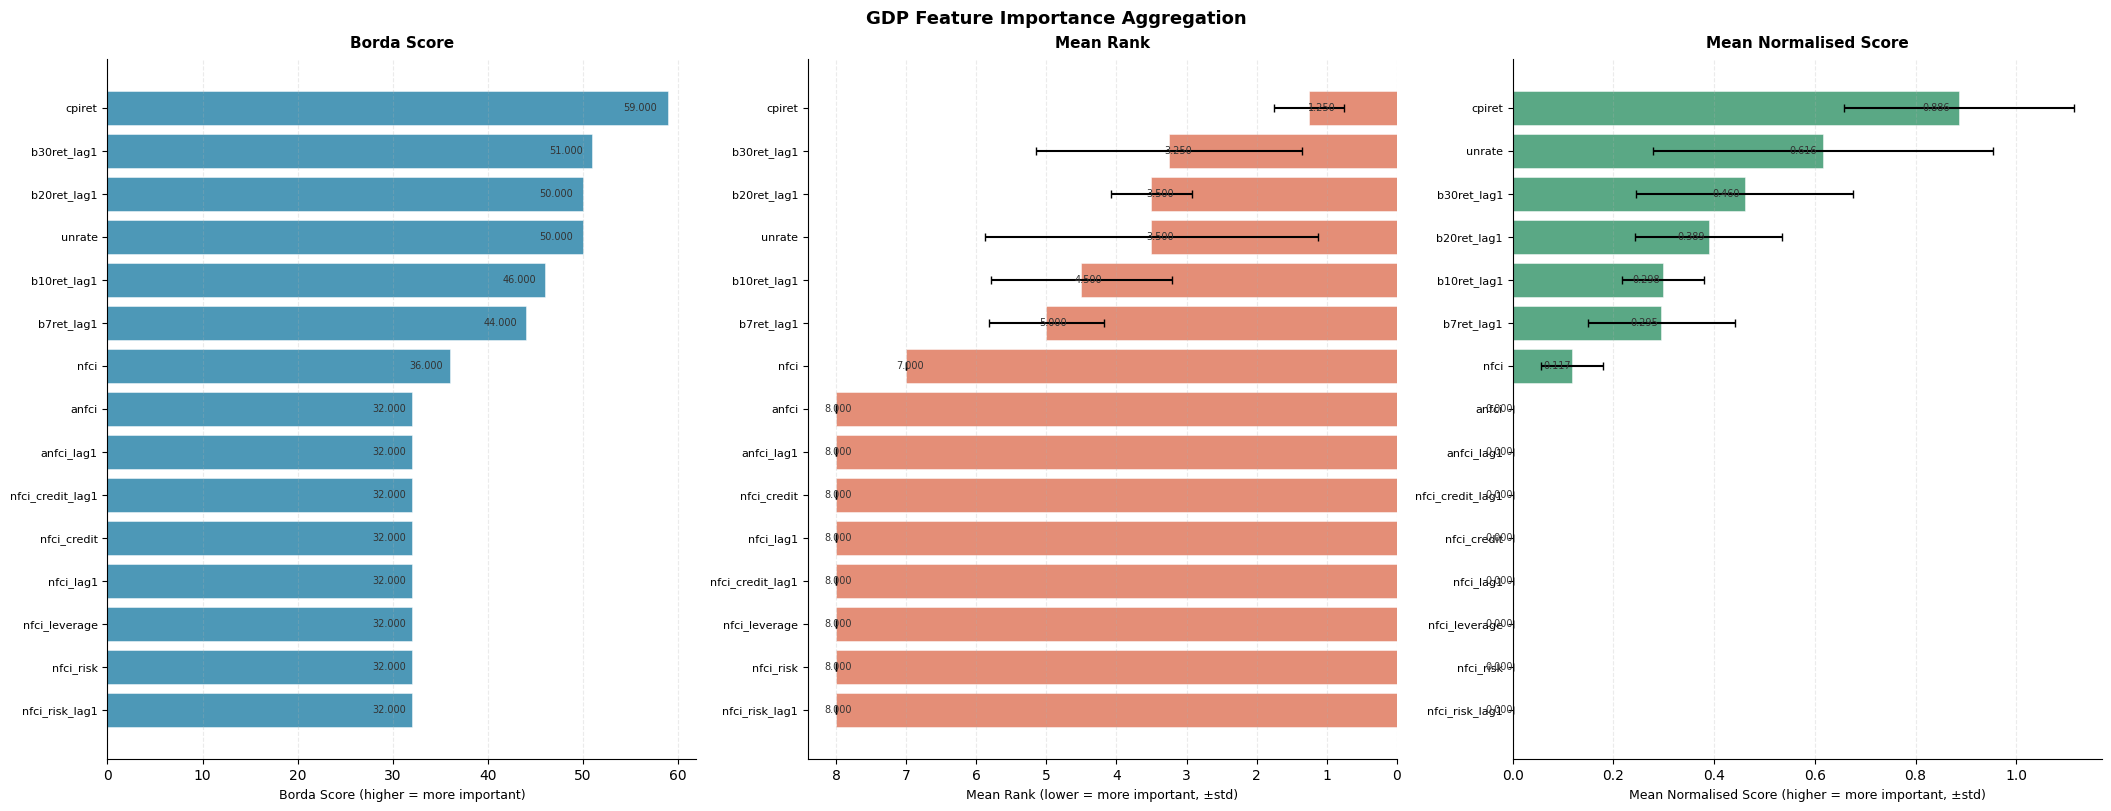


MODEL AGREEMENT — Top 10 features per model
  cpiret                         ████       4/4 (100%)
  unrate                         ████       4/4 (100%)
  b10ret_lag1                    ████       4/4 (100%)
  b20ret_lag1                    ████       4/4 (100%)
  b7ret_lag1                     ████       4/4 (100%)
  b30ret_lag1                    ████       4/4 (100%)
  nfci                           ████       4/4 (100%)
  nfci_leverage                  ████       4/4 (100%)
  nfci_credit                    ████       4/4 (100%)
  nfci_risk                      ████       4/4 (100%)


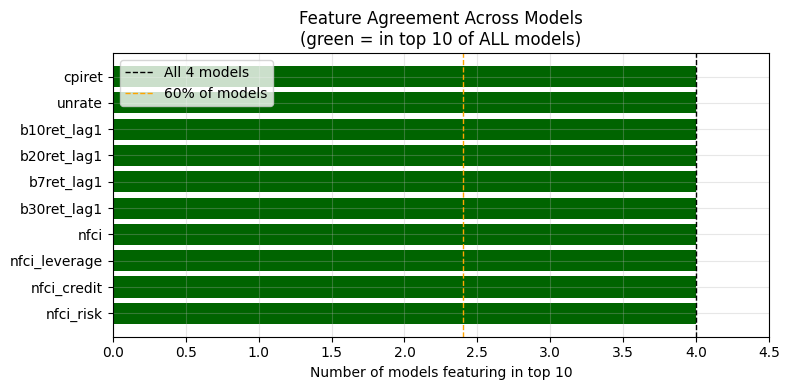

In [ ]:
importance_results = {
    'XGB':      xgb_fi_lime,
    'GB':       gb_fi_lime,
    'bayes':    bayes_fi_lime,
    'catboost': catboost_fi_lime
}

aggregated = aggregate_feature_importance(
    importance_results,
    top_n=20
)

vote_df = plot_model_agreement(importance_results, top_n=10)